<a href="https://colab.research.google.com/github/kjesinthuyaUCLL/kjesinthuya/blob/main/MBTI_Playlist_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1: Mount Google Drive and Load Data

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "/content/drive/My Drive/mbti_tune_data/"

# Load data
df = pd.read_csv(f"{DATA_PATH}/playlist_data.csv")
print(f"✅ Loaded {len(df)} playlists")

# Load feature names
with open(f"{DATA_PATH}/features.json", 'r') as f:
    feature_cols = json.load(f)

print(f"✅ Loaded {len(feature_cols)} features")

# Display basic stats
print(f"\n📊 Personality distribution:")
print(df['personality'].value_counts())

print(f"\n📊 Dimension balance:")
for dim in ['E', 'N', 'T', 'J']:
    print(f"   {dim}: {df[dim].mean()*100:.1f}%")

Mounted at /content/drive
✅ Loaded 4201 playlists
✅ Loaded 45 features

📊 Personality distribution:
personality
INTJ    307
ESTP    306
INFJ    304
ENTP    303
ENTJ    303
ENFP    302
ENFJ    302
ISTP    300
INTP    299
INFP    295
ISFP    295
ESFP    231
ISFJ    221
ISTJ    196
ESTJ    122
ESFJ    115
Name: count, dtype: int64

📊 Dimension balance:
   E: 47.2%
   N: 57.5%
   T: 50.8%
   J: 44.5%


In [2]:
# 2: Prepare Feature Matrix and Targets

# Handle any missing values
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

# Prepare X and y
X = df[feature_cols].values.astype(np.float32)
y = df[['E', 'N', 'T', 'J']].values.astype(np.float32)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Train/val/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df['personality']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=df[df.index.isin(range(len(X_temp)))]['personality'].values[:len(X_temp)]
)

print(f"\n📊 Split sizes:")
print(f"   Train: {len(X_train)}")
print(f"   Val:   {len(X_val)}")
print(f"   Test:  {len(X_test)}")

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(f"\n✅ Data ready for training")

X shape: (4201, 45)
y shape: (4201, 4)

📊 Split sizes:
   Train: 2940
   Val:   630
   Test:  631

✅ Data ready for training


In [3]:
# 3: Neural Network Architecture

class MBTINetwork(nn.Module):
    """
    Deep Neural Network for MBTI dimension prediction
    Input: 45 audio features (means + stds + key counts)
    Output: 4 dimensions (E, N, T, J) as percentages (0-1)
    """
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rates=[0.3, 0.3, 0.2]):
        super(MBTINetwork, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim, dropout in zip(hidden_dims, dropout_rates):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        # Output layer (no sigmoid - we'll use BCEWithLogitsLoss)
        layers.append(nn.Linear(prev_dim, 4))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create model
model = MBTINetwork(input_dim=X_train.shape[1])
model = model.to(device)

print(f"\n✅ Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"\nModel architecture:")
print(model)

Using device: cuda

✅ Model created with 16,804 parameters

Model architecture:
MBTINetwork(
  (network): Sequential(
    (0): Linear(in_features=45, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [4]:
# 4: Calculate Class Weights for Imbalance

def calculate_class_weights(y_train):
    """Calculate positive class weights for each dimension"""
    weights = []
    for i in range(4):
        n_pos = y_train[:, i].sum().item()
        n_neg = len(y_train) - n_pos
        if n_pos > 0:
            weight = n_neg / n_pos
        else:
            weight = 1.0
        weights.append(weight)
    return torch.tensor(weights, device=device)

# Convert y_train to numpy for calculation
pos_weights = calculate_class_weights(y_train)
print(f"Positive class weights (E,N,T,J):")
print(f"  E: {pos_weights[0]:.3f} (imbalance factor)")
print(f"  N: {pos_weights[1]:.3f}")
print(f"  T: {pos_weights[2]:.3f}")
print(f"  J: {pos_weights[3]:.3f}")

# Create weighted loss function
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

Positive class weights (E,N,T,J):
  E: 1.118 (imbalance factor)
  N: 0.741
  T: 0.968
  J: 1.246


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 5: Training Loop

def train_model(model, X_train, y_train, X_val, y_val, epochs=300, batch_size=32, lr=0.001):
    """Train the neural network"""

    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=30, factor=0.5)

    # Tracking
    train_losses = []
    val_losses = []
    val_accuracies = []
    best_val_loss = float('inf')

    print("="*60)
    print("TRAINING STARTING")
    print("="*60)
    print(f"Epochs: {epochs} | Batch size: {batch_size} | Learning rate: {lr}")
    print("-"*60)

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0
        all_preds = []
        all_targets = []

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                val_loss += criterion(outputs, batch_y).item()

                # Convert to probabilities
                preds = torch.sigmoid(outputs)
                all_preds.append(preds.cpu())
                all_targets.append(batch_y.cpu())

        # Calculate metrics
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)

        # Accuracy: prediction within 15% of actual
        accuracy = (torch.abs(all_preds - all_targets) < 0.15).float().mean().item()
        val_accuracies.append(accuracy)

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '/content/best_model.pth')

        # Print progress
        if (epoch + 1) % 30 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {accuracy:.2%}")

    print("-"*60)
    print("✅ TRAINING COMPLETE")
    print(f"Best validation loss: {best_val_loss:.4f}")

    return train_losses, val_losses, val_accuracies

# Train the model
train_losses, val_losses, val_accuracies = train_model(
    model, X_train, y_train, X_val, y_val,
    epochs=300, batch_size=32, lr=0.001
)

TRAINING STARTING
Epochs: 300 | Batch size: 32 | Learning rate: 0.001
------------------------------------------------------------
Epoch  30/300 | Train Loss: 0.5612 | Val Loss: 0.5949 | Acc: 10.67%
Epoch  60/300 | Train Loss: 0.5200 | Val Loss: 0.5986 | Acc: 16.11%
Epoch  90/300 | Train Loss: 0.4990 | Val Loss: 0.6061 | Acc: 18.33%
Epoch 120/300 | Train Loss: 0.4896 | Val Loss: 0.6148 | Acc: 19.80%
Epoch 150/300 | Train Loss: 0.4834 | Val Loss: 0.6144 | Acc: 19.96%
Epoch 180/300 | Train Loss: 0.4807 | Val Loss: 0.6203 | Acc: 21.90%
Epoch 210/300 | Train Loss: 0.4709 | Val Loss: 0.6168 | Acc: 21.23%
Epoch 240/300 | Train Loss: 0.4763 | Val Loss: 0.6156 | Acc: 20.71%
Epoch 270/300 | Train Loss: 0.4812 | Val Loss: 0.6195 | Acc: 21.98%
Epoch 300/300 | Train Loss: 0.4679 | Val Loss: 0.6179 | Acc: 21.55%
------------------------------------------------------------
✅ TRAINING COMPLETE
Best validation loss: 0.5910


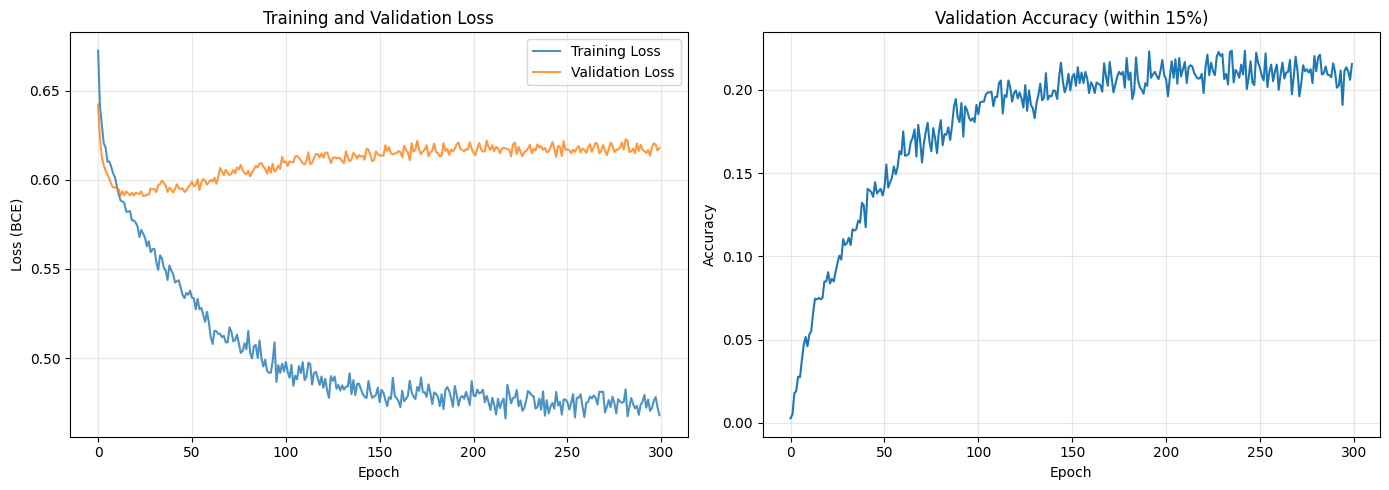

Final validation accuracy: 21.55%


In [7]:
# 6: Visualize Training Progress

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Training Loss', alpha=0.8)
axes[0].plot(val_losses, label='Validation Loss', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(val_accuracies)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy (within 15%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final validation accuracy: {val_accuracies[-1]:.2%}")

In [8]:
# 7: Test Set Evaluation

# Load best model
model.load_state_dict(torch.load('/content/best_model.pth'))

# Evaluate on test set
model.eval()
with torch.no_grad():
    X_test_device = X_test.to(device)
    outputs = model(X_test_device)
    predictions = torch.sigmoid(outputs).cpu().numpy()
    targets = y_test.numpy()

dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']
dim_letters = ['E', 'N', 'T', 'J']

print("="*60)
print("TEST SET RESULTS")
print("="*60)

results = {}
for i, (name, letter) in enumerate(zip(dim_names, dim_letters)):
    mae = mean_absolute_error(targets[:, i], predictions[:, i])
    r2 = r2_score(targets[:, i], predictions[:, i])
    results[letter] = {'mae': mae, 'r2': r2}
    print(f"\n{name} ({letter}):")
    print(f"  MAE:  {mae:.3f} ({mae*100:.1f}% avg error)")
    print(f"  R²:   {r2:.3f}")

# Overall metrics
overall_mae = mean_absolute_error(targets.flatten(), predictions.flatten())
accuracy_within_15 = (np.abs(predictions - targets) < 0.15).mean()
accuracy_within_10 = (np.abs(predictions - targets) < 0.10).mean()

print(f"\n{'='*60}")
print("OVERALL METRICS")
print(f"{'='*60}")
print(f"Overall MAE: {overall_mae:.3f} ({overall_mae*100:.1f}%)")
print(f"Accuracy (within 15%): {accuracy_within_15:.2%}")
print(f"Accuracy (within 10%): {accuracy_within_10:.2%}")

TEST SET RESULTS

Extraversion (E) (E):
  MAE:  0.346 (34.6% avg error)
  R²:   0.320

Intuition (N) (N):
  MAE:  0.461 (46.1% avg error)
  R²:   0.044

Thinking (T) (T):
  MAE:  0.371 (37.1% avg error)
  R²:   0.258

Judging (J) (J):
  MAE:  0.444 (44.4% avg error)
  R²:   0.089

OVERALL METRICS
Overall MAE: 0.405 (40.5%)
Accuracy (within 15%): 9.43%
Accuracy (within 10%): 3.65%


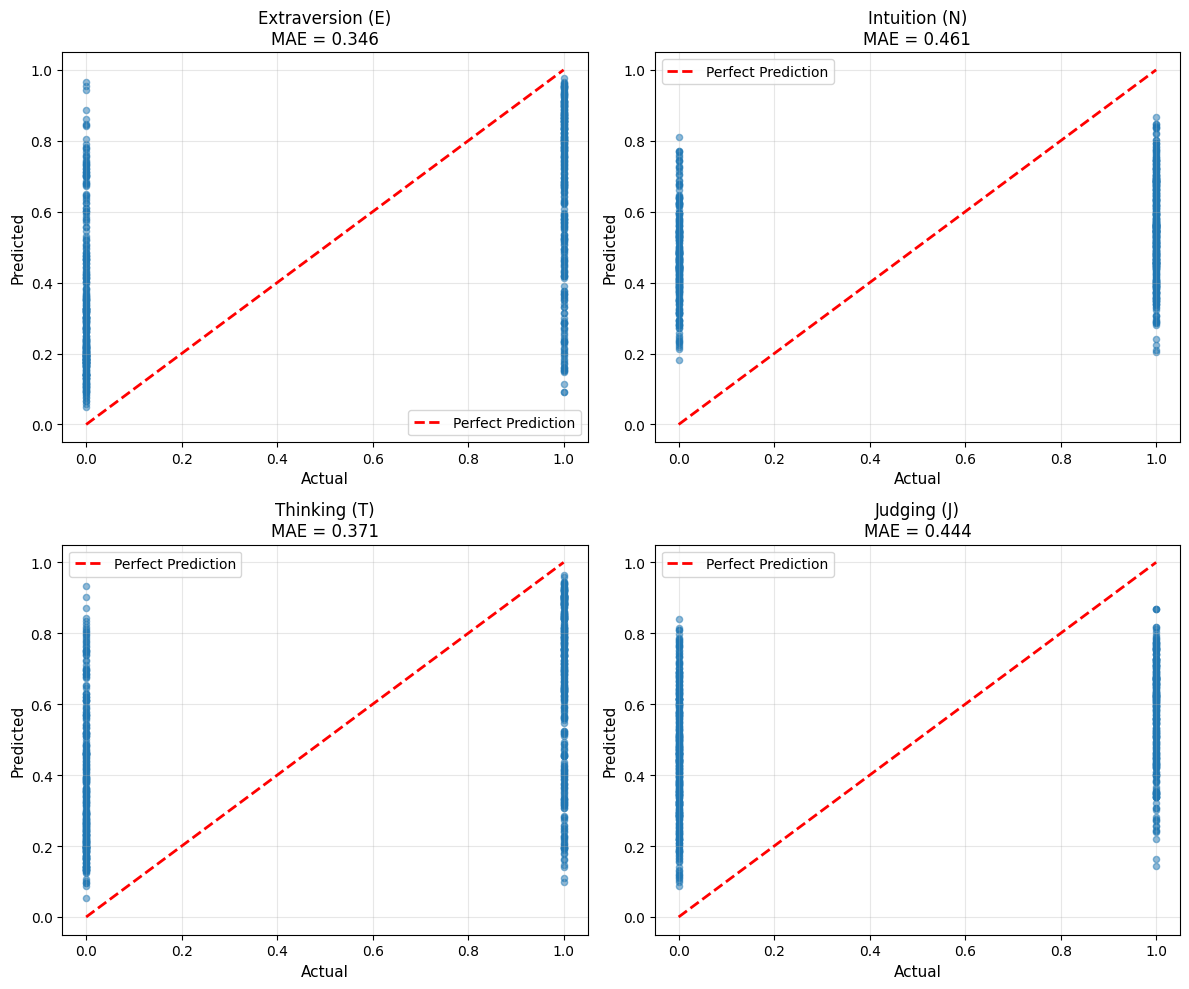

In [9]:
# 8: Predictions vs Actual Scatter Plot

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
dim_names = ['Extraversion (E)', 'Intuition (N)', 'Thinking (T)', 'Judging (J)']

for i, (name, ax) in enumerate(zip(dim_names, axes.flatten())):
    ax.scatter(targets[:, i], predictions[:, i], alpha=0.5, s=20)
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{name}\nMAE = {results[dim_letters[i]]["mae"]:.3f}', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()